# **QUANTIUM RETAIL ANALYTICS PROJECT**

# **Customer Purchasing Behaviour Analysis for the Chips Category**

## **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## **Load Datasets and Initial Data Inspection**

In [3]:
transactions=pd.read_excel(r"C:\Users\ACM\Documents\GitHub\Quantium\Retail Data Analysis\Data\QVI_transaction_data.xlsx")

In [4]:
transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
transactions.columns

Index(['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR',
       'PROD_NAME', 'PROD_QTY', 'TOT_SALES'],
      dtype='object')

In [6]:
transactions.shape

(264836, 8)

In [7]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [8]:
customers=pd.read_csv(r"C:\Users\ACM\Documents\GitHub\Quantium\Retail Data Analysis\Data\QVI_purchase_behaviour.csv")

In [9]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [10]:
customers.columns

Index(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER'], dtype='object')

In [11]:
customers.shape

(72637, 3)

In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


## **Data Cleaning**

#### *Checking for missing values in the dataset*

In [13]:
transactions.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

#### *Checking for duplicate transactions*

In [14]:
transactions.duplicated().sum()

np.int64(1)

#### *Removing the duplicate transactions*

In [15]:
transactions.drop_duplicates(inplace=True)

In [16]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835.000000,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,43464.036600,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
std,105.389336,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231
min,43282.000000,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,43646.000000,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


#### *Checking for missing values in the dataset*

In [17]:
customers.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

#### *Checking for duplicate Customers*

In [18]:
customers.duplicated().sum()

np.int64(0)

In [19]:
customers.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


## **Fix Data Type**

#### *Converting DATE column to datetime format*

In [20]:
transactions["DATE"]=pd.to_datetime(
    transactions["DATE"],
    unit="D",
    origin="1899-12-30"
)    

In [21]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,2018-12-30 00:52:42.252722944,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231


## **Outlier Detection**

#### *Checking for unusually high quantity purchases to reduce outlier impact*

Text(0.5, 1.0, 'Distribution of Product Quantity')

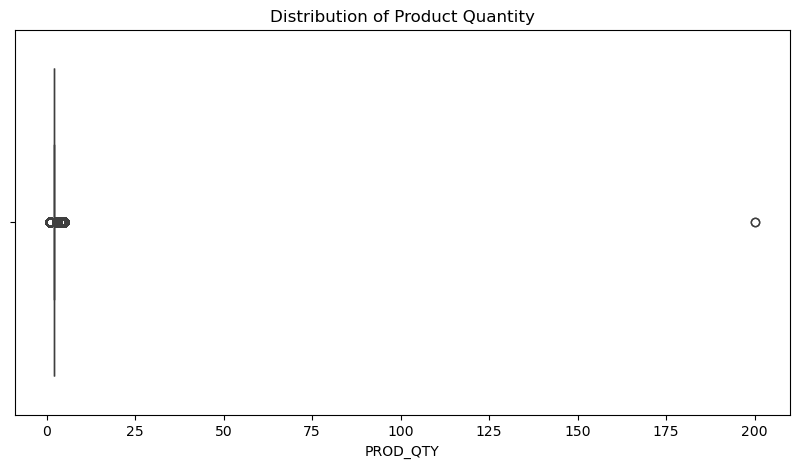

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(x=transactions["PROD_QTY"])

plt.title("Distribution of Product Quantity")

## **Remove Outliers**

#### *Removing unusually high quantity purchases to reduce outlier impact*

In [23]:
transactions=transactions[transactions["PROD_QTY"]<10]

Text(0.5, 1.0, 'Distribution of Product Quantity')

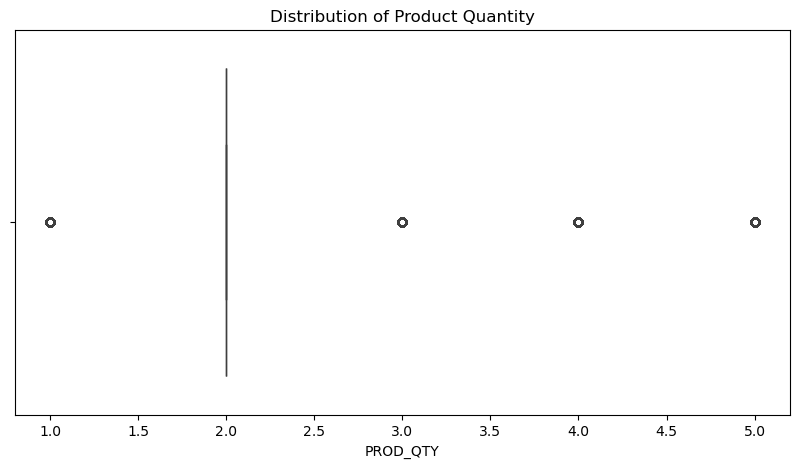

In [24]:
plt.figure(figsize=(10,5))

sns.boxplot(x=transactions["PROD_QTY"])

plt.title("Distribution of Product Quantity")

In [25]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264833,264833.000000,2.648330e+05,2.648330e+05,264833.000000,264833.000000,264833.000000
mean,2018-12-30 00:52:39.666657792,135.079529,1.355489e+05,1.351577e+05,56.583598,1.905812,7.299351
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760000e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351370e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.027000e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.784189,8.058003e+04,7.813305e+04,32.826498,0.343437,2.527244


## **Feature Engineering**

### **Extract Pack Size**

#### *Extracting Pack sizes from product names*

In [26]:
transactions["PACK_SIZE"]=transactions["PROD_NAME"].str.extract('(\d+)')
transactions["PACK_SIZE"]=transactions["PACK_SIZE"].astype(float)

In [27]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,264833,264833.000000,2.648330e+05,2.648330e+05,264833.000000,264833.000000,264833.000000,264833.000000
mean,2018-12-30 00:52:39.666657792,135.079529,1.355489e+05,1.351577e+05,56.583598,1.905812,7.299351,182.425540
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760000e+04,28.000000,2.000000,5.400000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351370e+05,56.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.027000e+05,85.000000,2.000000,9.200000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.784189,8.058003e+04,7.813305e+04,32.826498,0.343437,2.527244,64.325268


### **Extract Brand Name**

#### *Extracting brand names from product names*

In [28]:
transactions["BRAND"]=transactions["PROD_NAME"].str.split().str[0]

In [29]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE
count,264833,264833.000000,2.648330e+05,2.648330e+05,264833.000000,264833.000000,264833.000000,264833.000000
mean,2018-12-30 00:52:39.666657792,135.079529,1.355489e+05,1.351577e+05,56.583598,1.905812,7.299351,182.425540
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000,70.000000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760000e+04,28.000000,2.000000,5.400000,150.000000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351370e+05,56.000000,2.000000,7.400000,170.000000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.027000e+05,85.000000,2.000000,9.200000,175.000000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000
std,NaN,76.784189,8.058003e+04,7.813305e+04,32.826498,0.343437,2.527244,64.325268


In [30]:
transactions["BRAND"].value_counts()

BRAND
Kettle        41288
Smiths        28859
Pringles      25102
Doritos       24962
Thins         14075
RRD           11894
Infuzions     11057
WW            10320
Cobs           9693
Tostitos       9471
Twisties       9454
Old            9324
Tyrrells       6442
Grain          6272
Natural        6050
Red            5885
Cheezels       4603
CCs            4551
Woolworths     4437
Dorito         3183
Infzns         3144
Smith          2963
Cheetos        2927
Snbts          1576
Burger         1564
GrnWves        1468
Sunbites       1432
NCC            1419
French         1418
Name: count, dtype: int64

## **Merge Datasets**

#### *Merging transaction and customer datasets*

In [31]:
data=pd.merge(transactions,customers,on="LYLTY_CARD_NBR")

In [32]:
data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


## **KPI Summary**

In [33]:
total_revenue = transactions["TOT_SALES"].sum()
total_customers = transactions["LYLTY_CARD_NBR"].nunique()
total_transactions = transactions.shape[0]
avg_transaction = transactions["TOT_SALES"].mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Customers:", total_customers)
print("Total Transactions:", total_transactions)
print("Average Transaction Value:", round(avg_transaction,2))

Total Revenue: 1933109.0
Total Customers: 72636
Total Transactions: 264833
Average Transaction Value: 7.3


# **Exploratory Data Analysis**

## **Monthly Sales Trend Analysis**

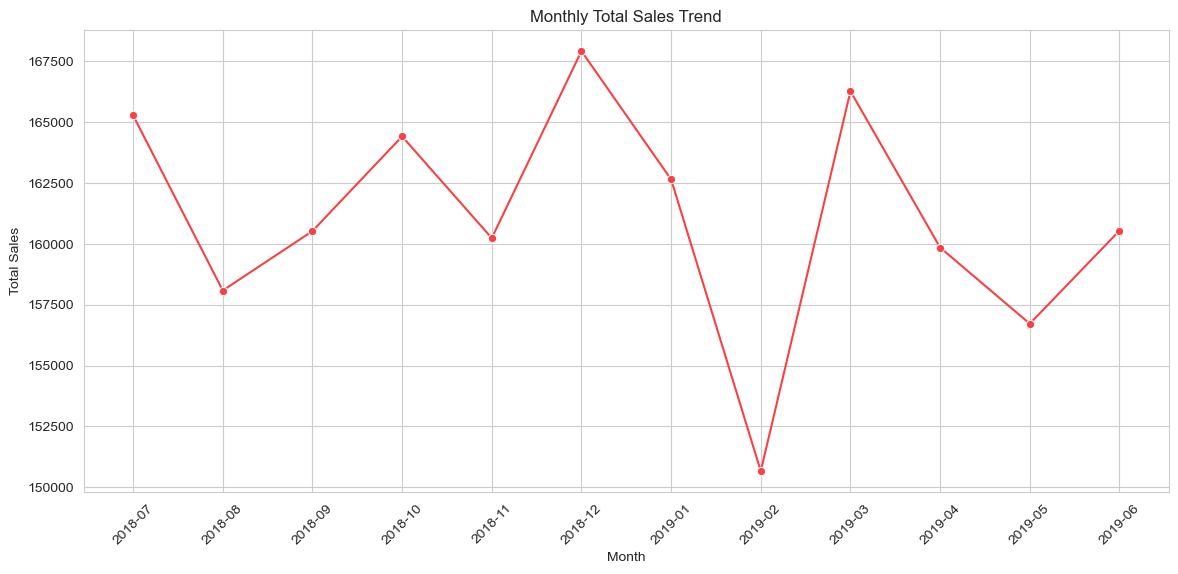

In [53]:
monthly_sales=(
    data.groupby(
        data["DATE"].dt.to_period("M")
    )["TOT_SALES"]
        .sum()
        .reset_index()
)    

monthly_sales.columns = [
    "MONTH",
    "TOTAL_SALES"
]

monthly_sales["MONTH"] = (
    monthly_sales["MONTH"]
    .astype(str)
)
plt.figure(figsize=(14,6))
sns.set_style("whitegrid")

sns.lineplot(
    data=monthly_sales,
    x="MONTH",
    y="TOTAL_SALES",
    marker="o", color="#F94144"
)

plt.xticks(rotation=45)
plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")    

plt.savefig(
    "monthly sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Customer Segment Analysis**

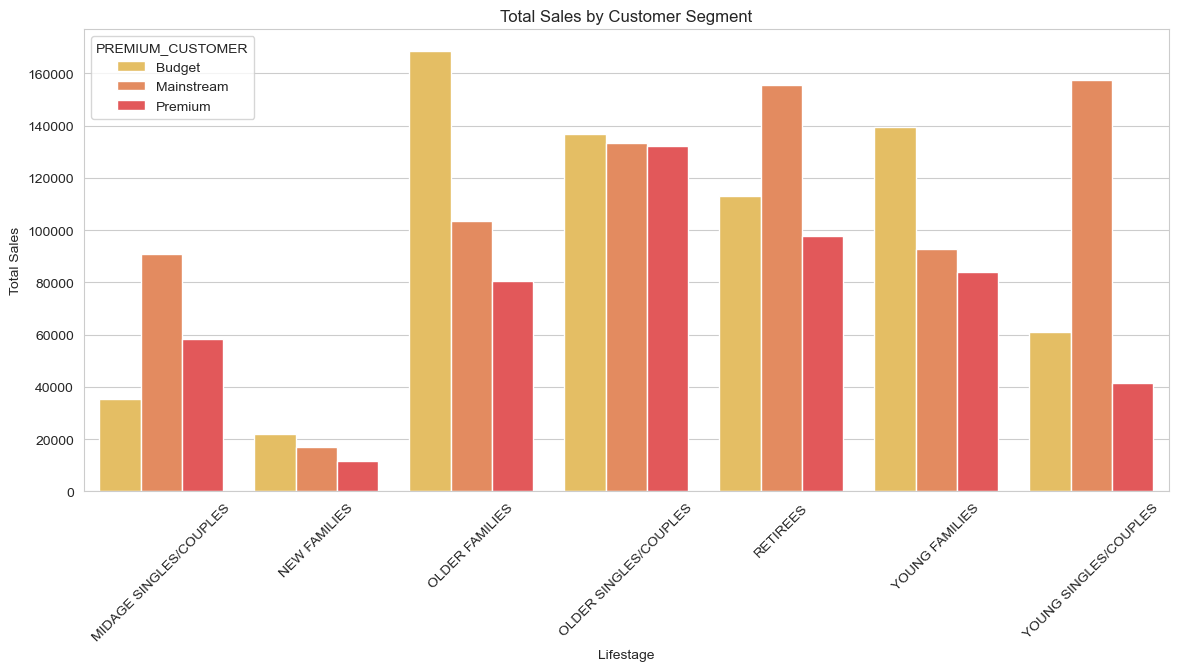

In [35]:
segment_sales=data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum().reset_index()

plt.figure(figsize=(14,6))
sns.set_style("whitegrid")

sns.barplot(
    data=segment_sales,
    x="LIFESTAGE",
    y="TOT_SALES",
    hue="PREMIUM_CUSTOMER",
    palette=["#F9C74F", "#F9844A", "#F94144"],
)
plt.xticks(rotation=45)
plt.title("Total Sales by Customer Segment")
plt.xlabel("Lifestage")
plt.ylabel("Total Sales")

plt.savefig("graph3.png", dpi=300,
  bbox_inches='tight')

## **Average Spend per Customer**

C:\Users\ACM\AppData\Local\Temp\ipykernel_14840\3630775037.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


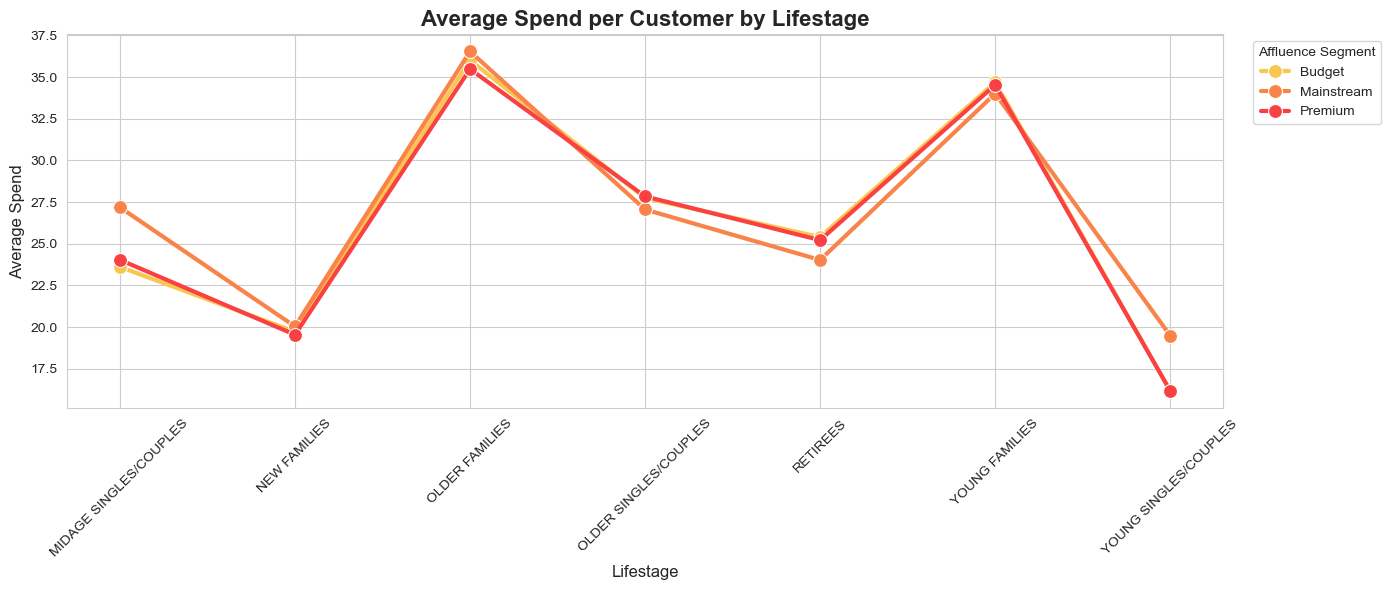

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

avg_spend = data.groupby(
    ["LIFESTAGE", "PREMIUM_CUSTOMER"]
).apply(
    lambda x: x["TOT_SALES"].sum() /
              x["LYLTY_CARD_NBR"].nunique()
).reset_index(name="AVG_SPEND")

plt.figure(figsize=(14,6))

sns.set_style("whitegrid")

sns.lineplot(
    data=avg_spend,
    x="LIFESTAGE",
    y="AVG_SPEND",
    hue="PREMIUM_CUSTOMER",
    marker="o",
    linewidth=3,
    markersize=10,
    palette=["#F9C74F", "#F9844A", "#F94144"]
)

plt.title(
    "Average Spend per Customer by Lifestage",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Lifestage", fontsize=12)
plt.ylabel("Average Spend", fontsize=12)

plt.xticks(rotation=45)

plt.legend(
    title="Affluence Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# Save graph for PowerPoint
plt.savefig(
    "Average_Spend_Per_Customer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## **Customer Proportion by Life Stage and Affluence**

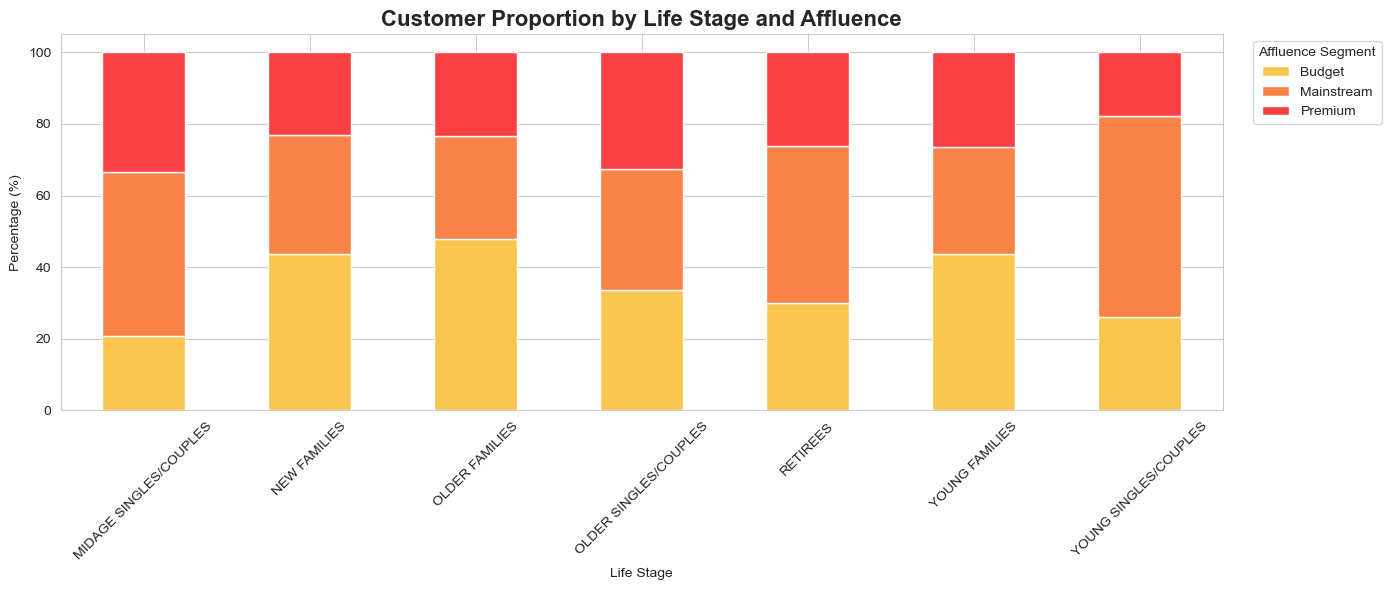

In [37]:
customer_prop = (
    data.groupby(
        ['LIFESTAGE','PREMIUM_CUSTOMER']
    )['LYLTY_CARD_NBR']
    .nunique()
    .reset_index(name='CUSTOMERS')
)

pivot_df = customer_prop.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='CUSTOMERS'
)

pivot_df = pivot_df.div(
    pivot_df.sum(axis=1),
    axis=0
) * 100

pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6),
    color=['#F9C74F','#F9844A','#F94144']
)

plt.title(
    'Customer Proportion by Life Stage and Affluence',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Percentage (%)')
plt.xlabel('Life Stage')

plt.xticks(rotation=45)

plt.legend(
    title='Affluence Segment',
    bbox_to_anchor=(1.02,1)
)

plt.tight_layout()

plt.savefig(
    'Customer_Proportion.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## **Average Product Quantity**

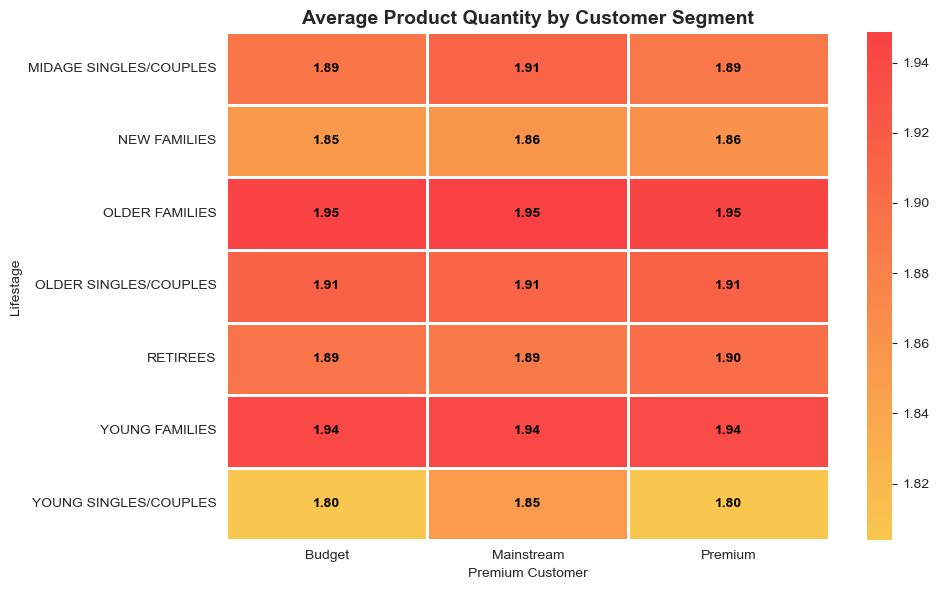

In [54]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_palette",
    ["#F9C74F", "#F9844A", "#F94144"]
)

pivot_table = avg_qty.pivot(
    index="LIFESTAGE",
    columns="PREMIUM_CUSTOMER",
    values="PROD_QTY"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap=custom_cmap,
    fmt=".2f",
    linewidths=1,
    linecolor="white",
    annot_kws={"size":10, "weight":"bold", "color":"black"}
)

plt.title("Average Product Quantity by Customer Segment", fontsize=14, fontweight="bold")
plt.xlabel("Premium Customer")
plt.ylabel("Lifestage")

plt.tight_layout()
plt.show()

## **Purchase Frequency Analysis**

Text(0, 0.5, 'Frequency')

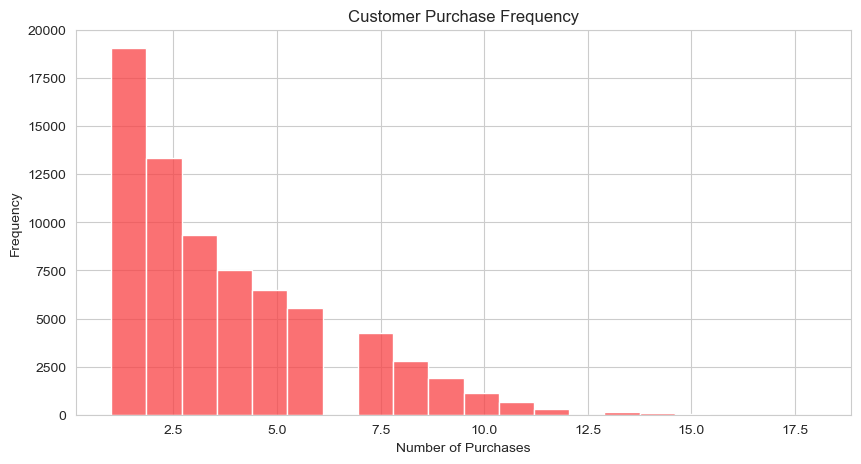

In [47]:
purchase_frequency = data.groupby(
    "LYLTY_CARD_NBR"
)["DATE"].count().reset_index()

purchase_frequency.columns=[
    "CUSTOMER_ID", 
    "PURCHASE_COUNT"
]

plt.figure(figsize=(10,5))

sns.histplot( purchase_frequency["PURCHASE_COUNT"], bins=20, color="#F94144")

plt.title("Customer Purchase Frequency") 
plt.xlabel("Number of Purchases") 
plt.ylabel("Frequency")

## **Price per Unit Variable**

In [40]:
data["PRICE_PER_UNIT"]=data["TOT_SALES"]/data["PROD_QTY"]

In [41]:
data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,PACK_SIZE,PRICE_PER_UNIT
count,264833,264833.000000,2.648330e+05,2.648330e+05,264833.000000,264833.000000,264833.000000,264833.000000,264833.000000
mean,2018-12-30 00:52:39.666657792,135.079529,1.355489e+05,1.351577e+05,56.583598,1.905812,7.299351,182.425540,3.824632
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000,70.000000,1.320000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760000e+04,28.000000,2.000000,5.400000,150.000000,3.000000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351370e+05,56.000000,2.000000,7.400000,170.000000,3.800000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.027000e+05,85.000000,2.000000,9.200000,175.000000,4.600000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000,380.000000,6.500000
std,NaN,76.784189,8.058003e+04,7.813305e+04,32.826498,0.343437,2.527244,64.325268,1.109527


## **Price per Unit Analysis**

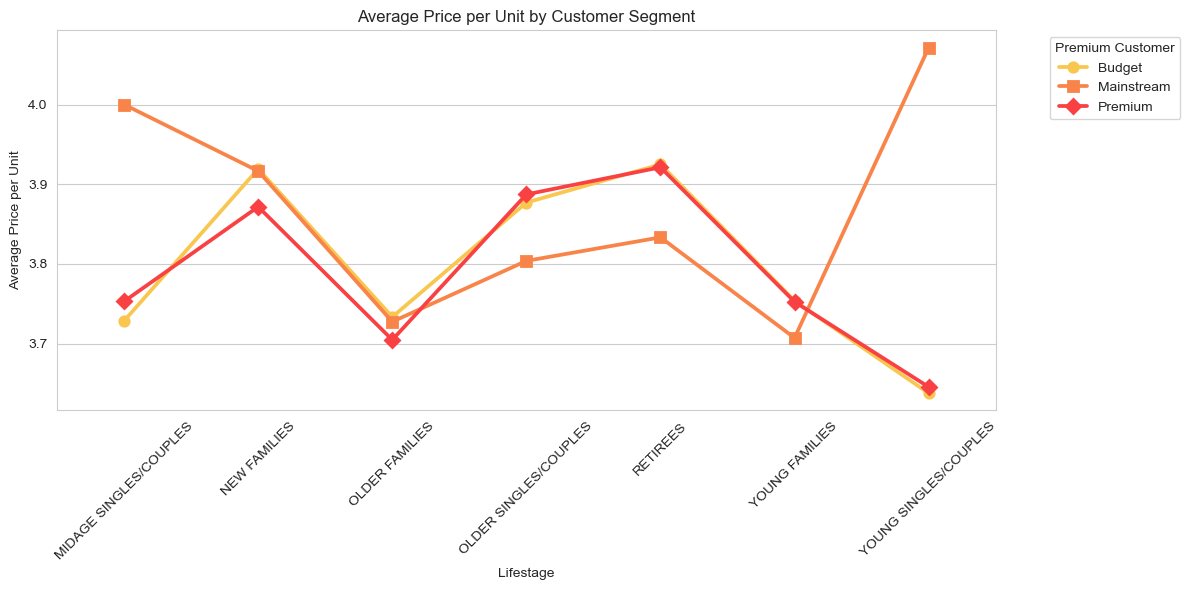

In [56]:
plt.figure(figsize=(12,6))

sns.pointplot(
    data=price_analysis,
    x="LIFESTAGE",
    y="PRICE_PER_UNIT",
    hue="PREMIUM_CUSTOMER",
    palette=["#F9C74F", "#F9844A", "#F94144"],
    markers=["o", "s", "D"],
    linestyles="-"
)

plt.xticks(rotation=45)
plt.title("Average Price per Unit by Customer Segment")
plt.xlabel("Lifestage")
plt.ylabel("Average Price per Unit")

plt.legend(
    title="Premium Customer",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## **Brand Analysis**

Text(0, 0.5, 'Total Sales')

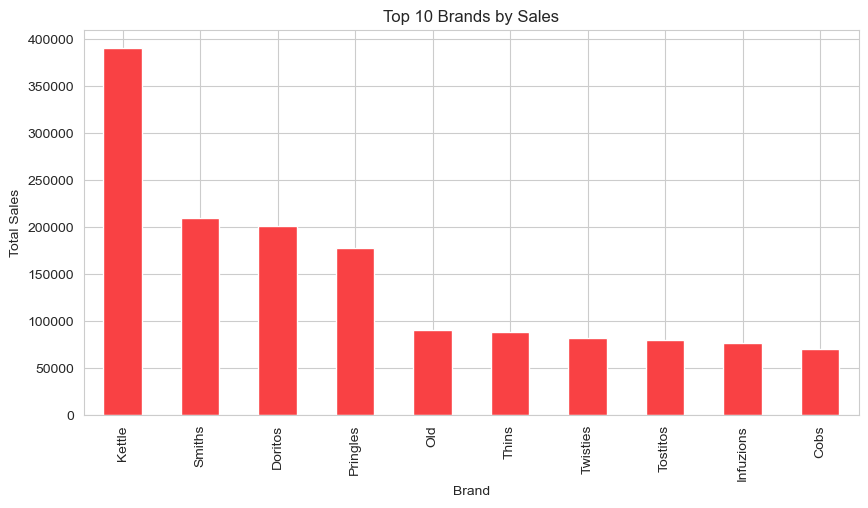

In [48]:
brand_sales=data.groupby("BRAND")["TOT_SALES"].sum().sort_values(
    ascending=False
)

brand_sales.head(10).plot(kind="bar",figsize=(10,5), color="#F94144")
sns.set_style("whitegrid")

plt.title("Top 10 Brands by Sales")
plt.xlabel("Brand")
plt.ylabel("Total Sales")

## **Top Product Analysis**

Text(0, 0.5, 'Product')

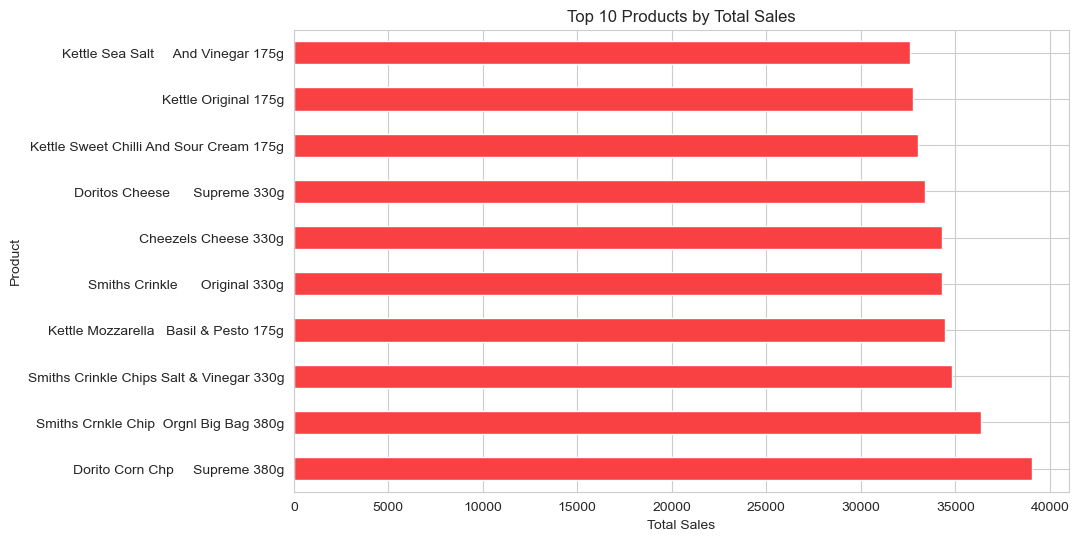

In [49]:
top_products = data.groupby( 
    "PROD_NAME" 
)["TOT_SALES"].sum().sort_values( 
    ascending=False 
).head(10)
sns.set_style("whitegrid")

top_products.plot( 
    kind="barh", figsize=(10,6), color="#F94144"
) 
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales") 
plt.ylabel("Product")

## **Pack Size Analysis**

Text(0.5, 1.0, 'Pack Size Distribution')

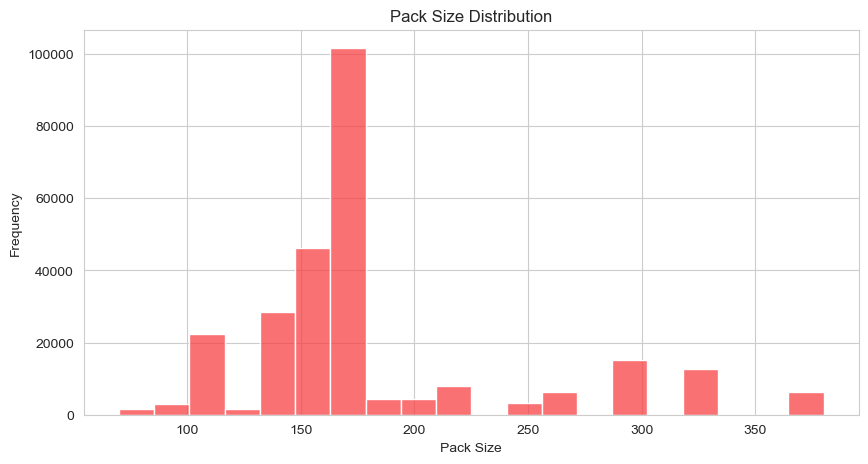

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(data["PACK_SIZE"], bins=20, color="#F94144")
plt.xlabel('Pack Size')
plt.ylabel('Frequency')
plt.title("Pack Size Distribution")

## **Correlation Analysis**

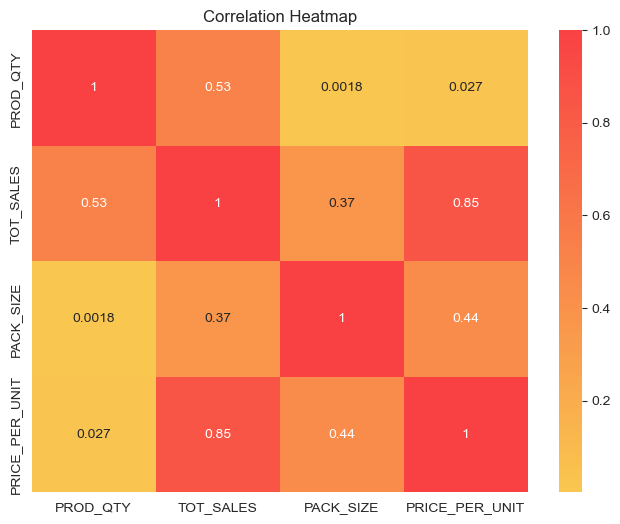

In [57]:
from matplotlib.colors import LinearSegmentedColormap

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_palette",
    ["#F9C74F", "#F9844A", "#F94144"]
)

numeric_columns=data[
    [
        "PROD_QTY",
        "TOT_SALES",
        "PACK_SIZE",
        "PRICE_PER_UNIT"
    ]
]

correlation=numeric_columns.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap=custom_cmap
)

plt.title("Correlation Heatmap")
plt.show()


#### *A strong positive relationship exists between product quantity and total sales. This indicates that larger purchases contribute significantly to revenue generation.*

#  📊 **Insights**


### 🏆 *A few leading brands contribute the highest share of total revenue.*

### 📦 *Larger pack sizes generate more sales compared to smaller packs.*

### 👥 *Customer spending patterns vary across different customer segments.*

### 💰 *Higher product quantity purchases strongly increase total sales.*

### 🔥 *Some products consistently perform better in terms of revenue and demand.*

### 📈 *Monthly sales trends show fluctuations in customer purchasing behavior.*

### 🛒 *Most customers prefer value-for-money products and bulk purchases.*

### 💎 *Premium customers contribute significantly to overall revenue.*

### 💵 *Product pricing influences customer purchasing quantity.*

### ❤️ *Certain brands have stronger customer loyalty and repeat purchases.*

# 🚀 **Recommendations**

### 📦 *Increase inventory for top-performing brands and products.*

### 🎁 *Offer bundle discounts on larger pack sizes to boost bulk purchases.*

### 🎯 *Target high-value customers with personalized promotions.*

### 📢 *Improve marketing strategies for premium customer segments.*

### 📉 *Monitor low-performing products and optimize product assortment.*

### 📆 *Use seasonal sales trends for better inventory planning.*

### 🎖️ *Introduce loyalty rewards to improve customer retention.*

### 🔥 *Focus promotional campaigns on high-demand product categories.*

### 💲 *Optimize pricing strategies based on customer purchase behavior.*

### 🧠 *Use customer segmentation for targeted marketing campaigns.*

In [ ]:
data.to_csv('Retail Data Analysis.csv',index=False)

print("file saved successfully")